## Windkessel-Informed Neural Network for Cuffless BP Estimation 
==========================================================================

Physics constraint: 2-element Windkessel diastolic decay equation
 ##   DBP = SBP * exp(-decay_time / RC) ##
 
This constrains DBP to be consistent with the model's own SBP prediction
and the measured diastolic decay time (systolic peak -> dicrotic notch).
SBP remains purely data-driven (see explanation in accompanying chat message).
 
Sections:

    -  Peak / dicrotic notch detection  (feature extraction from raw PPG)

    -  RC estimation                    (fit once from training data)

    -  Windkessel physics loss          (the actual PINN constraint)

    - Model architecture               (simple 1D CNN)

    - Training loop                    (combines data loss + physics loss)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import find_peaks
import numpy as np
import h5py

from tqdm import tqdm

from scipy.signal import find_peaks

from sklearn.model_selection import train_test_split

import torch

from torch.utils.data import Dataset, DataLoader

## Peak / Dicrotic Notch detection ##

Systolic peak = start of the "pressure is falling" phase, and dicrotic notch = the precise physiological start of diastole, where the heart is no longer pushing anything in.

For this eqn - P(t) = P_sys · exp(-t / RC)

We need t = decay time, which is simply the number of seconds it takes for arterial pressure to go from its systolic peak down to the start of the diastolic (passive) phase, measured as the time gap between the systolic peak and the dicrotic notch on the PPG waveform.

In [21]:
from scipy.signal import find_peaks, savgol_filter
import numpy as np


def get_systolic_peak(ppg_window, fs=125):

    peaks, _ = find_peaks(
        ppg_window,
        height=np.mean(ppg_window),
        distance=int(0.3 * fs),
        prominence=0.3
    )

    if len(peaks) == 0:
        return None

    # Highest peak = systolic peak
    sys_idx = peaks[
        np.argmax(ppg_window[peaks])
    ]

    return sys_idx

In [22]:
def get_dicrotic_notch(
    ppg_window,
    sys_idx,
    fs=125
):

    if sys_idx is None:
        return None


    # -----------------------------------------
    # Smooth signal
    # -----------------------------------------

    smooth_ppg = savgol_filter(
        ppg_window,
        window_length=11,
        polyorder=3
    )


    # -----------------------------------------
    # Derivative
    # -----------------------------------------

    derivative = np.gradient(
        smooth_ppg
    )


    # -----------------------------------------
    # Search region
    #
    # Notch should occur after systolic
    # peak but BEFORE the diastolic trough
    # -----------------------------------------

    search_start = (
        sys_idx + int(0.05 * fs)
    )

    search_end = min(
        sys_idx + int(0.35 * fs),
        len(ppg_window) - 1
    )


    if search_start >= search_end:
        return None


    # -----------------------------------------
    # Find local minima in PPG
    # -----------------------------------------

    segment = smooth_ppg[
        search_start:search_end
    ]

    minima, _ = find_peaks(
        -segment,
        prominence=0.02
    )


    if len(minima) == 0:
        return None


    # -----------------------------------------
    # Choose the earliest minimum
    # -----------------------------------------

    notch_idx = (
        search_start + minima[0]
    )


    return notch_idx

In [23]:
def get_decay_time(ppg_window, fs=125):
    """
    Returns diastolic decay time (systolic peak -> dicrotic notch), in seconds.
    Returns None if either landmark could not be detected (caller should
    skip / fall back to a dataset-median value for that sample).
    """
    sys_idx = get_systolic_peak(ppg_window, fs)
    notch_idx = get_dicrotic_notch(ppg_window, sys_idx, fs)
    if sys_idx is None or notch_idx is None:
        return None
    return (notch_idx - sys_idx) / fs

In [24]:
def extract_decay_times(ppg_windows, fs=125, fallback='median'):
    """
    Runs decay-time extraction over a full array of PPG windows (N, L).
    Failed detections are filled with the median of successful ones.
    Returns: np.array of shape (N,)
    """
    decay_times = []
    for w in ppg_windows:
        dt = get_decay_time(w, fs)
        decay_times.append(dt)
 
    decay_times = np.array([d if d is not None else np.nan for d in decay_times])
    valid = decay_times[~np.isnan(decay_times)]
    if fallback == 'median' and len(valid) > 0:
        med = np.median(valid)
        decay_times = np.where(np.isnan(decay_times), med, decay_times)
    return decay_times.astype(np.float32)

In [25]:
def extract_bp_from_abp(abp_window):

    # --------------------------------------------------------
    # Detect systolic peaks in ABP
    # --------------------------------------------------------

    peaks, _ = find_peaks(
        abp_window,
        distance=50,
        prominence=5
    )


    # Need at least two beats
    if len(peaks) < 2:
        return None, None


    # --------------------------------------------------------
    # SBP
    # --------------------------------------------------------

    sbp_values = abp_window[peaks]


    # --------------------------------------------------------
    # DBP
    # --------------------------------------------------------

    dbp_values = []


    for i in range(len(peaks) - 1):

        beat_segment = abp_window[
            peaks[i]:peaks[i + 1]
        ]

        if len(beat_segment) > 0:

            dbp_values.append(
                np.min(beat_segment)
            )


    if len(dbp_values) == 0:
        return None, None


    # --------------------------------------------------------
    # Median across beats
    # --------------------------------------------------------

    sbp = np.median(
        sbp_values
    )

    dbp = np.median(
        dbp_values
    )


    # --------------------------------------------------------
    # Sanity checks
    # --------------------------------------------------------

    if sbp < 50 or sbp > 250:
        return None, None

    if dbp < 20 or dbp > 150:
        return None, None

    if dbp >= sbp:
        return None, None


    return (
        sbp,
        dbp
    )


In [26]:
def process_recording(
    recording,
    WINDOW_SIZE,
    STEP_SIZE,
    fs=125
):

    data = recording[:]


    # ------------------------------------------------
    # Extract PPG and ABP
    # ------------------------------------------------

    ppg = data[:, 0]
    abp = data[:, 1]


    # ------------------------------------------------
    # Recording-level normalization
    # ------------------------------------------------

    std = np.std(ppg)

    if std == 0:

        return None, None, None


    ppg = (
        ppg - np.mean(ppg)
    ) / std


    # ------------------------------------------------
    # Window storage
    # ------------------------------------------------

    X = []
    y = []


    # ------------------------------------------------
    # Windowing
    # ------------------------------------------------

    for start in range(
        0,
        len(ppg) - WINDOW_SIZE + 1,
        STEP_SIZE
    ):

        end = (
            start + WINDOW_SIZE
        )


        ppg_window = ppg[
            start:end
        ]

        abp_window = abp[
            start:end
        ]


        # --------------------------------------------
        # Extract SBP / DBP from ABP
        # --------------------------------------------

        sbp, dbp = extract_bp_from_abp(
            abp_window
        )


        if sbp is None:

            continue


        X.append(
            ppg_window
        )

        y.append(
            [sbp, dbp]
        )


    # ------------------------------------------------
    # No valid windows
    # ------------------------------------------------

    if len(X) == 0:

        return None, None, None


    X = np.array(
        X,
        dtype=np.float32
    )

    y = np.array(
        y,
        dtype=np.float32
    )


    # ------------------------------------------------
    # Extract PPG systolic -> notch delay
    # ------------------------------------------------

    decay_times = extract_decay_times(
        X,
        fs=fs,
        fallback="median"
    )


    return (
        X,
        y,
        decay_times
    )

In [27]:
def process_split(
    record_list,
    WINDOW_SIZE,
    STEP_SIZE
):

    X_all = []
    y_all = []
    decay_all = []

    skipped = 0


    for f, ref in tqdm(
        record_list
    ):

        recording = f[ref]


        X, y, decay_times = process_recording(
            recording,
            WINDOW_SIZE,
            STEP_SIZE
        )


        if X is None:

            skipped += 1

            continue


        X_all.append(X)
        y_all.append(y)
        decay_all.append(decay_times)


    # ------------------------------------------------
    # Concatenate all recordings
    # ------------------------------------------------

    X_all = np.concatenate(
        X_all,
        axis=0
    )

    y_all = np.concatenate(
        y_all,
        axis=0
    )

    decay_all = np.concatenate(
        decay_all,
        axis=0
    )


    print(
        "Skipped recordings:",
        skipped
    )

    print(
        "X shape:",
        X_all.shape
    )

    print(
        "y shape:",
        y_all.shape
    )

    print(
        "Decay-time shape:",
        decay_all.shape
    )


    return (
        X_all,
        y_all,
        decay_all
    )

In [28]:
DATA_PATH = (
    "/data1/yashvi_bhuva/"
    "BP_estimation_using_PPG/"
    "UCI/data"
)
from tqdm import tqdm
from sklearn.model_selection import train_test_split
def load_UCI_dataset(
    WINDOW_SIZE,
    STEP_SIZE,
    data_path=DATA_PATH,
    test_size=0.2,
    val_size=0.1,
    random_state=42
):

    # ========================================================
    # Load recording references
    # ========================================================

    recordings = []


    for part in range(1, 5):

        file_path = (
            f"{data_path}/Part_{part}.mat"
        )


        f = h5py.File(
            file_path,
            "r"
        )


        dataset = f[
            f"Part_{part}"
        ]


        for i in range(
            dataset.shape[0]
        ):

            recordings.append(
                (
                    f,
                    dataset[i, 0]
                )
            )


    print(
        "Total recordings:",
        len(recordings)
    )


    # ========================================================
    # Train / Test split
    # ========================================================

    train_records, test_records = train_test_split(
        recordings,
        test_size=test_size,
        random_state=random_state,
        shuffle=True
    )


    # ========================================================
    # Train / Validation split
    # ========================================================

    train_records, val_records = train_test_split(
        train_records,
        test_size=val_size,
        random_state=random_state,
        shuffle=True
    )


    print(
        f"Train recordings: "
        f"{len(train_records)}"
    )

    print(
        f"Validation recordings: "
        f"{len(val_records)}"
    )

    print(
        f"Test recordings: "
        f"{len(test_records)}"
    )


    # ========================================================
    # Process recordings
    # ========================================================

    print("\nProcessing training recordings...")

    (
        X_train,
        y_train,
        decay_train
    ) = process_split(
        train_records,
        WINDOW_SIZE,
        STEP_SIZE
    )


    print("\nProcessing validation recordings...")

    (
        X_val,
        y_val,
        decay_val
    ) = process_split(
        val_records,
        WINDOW_SIZE,
        STEP_SIZE
    )


    print("\nProcessing test recordings...")

    (
        X_test,
        y_test,
        decay_test
    ) = process_split(
        test_records,
        WINDOW_SIZE,
        STEP_SIZE
    )


    # ========================================================
    # Add CNN channel dimension
    # ========================================================

    X_train = X_train[:, None, :]
    X_val = X_val[:, None, :]
    X_test = X_test[:, None, :]


    # ========================================================
    # Convert to tensors
    # ========================================================

    X_train = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_val = torch.tensor(
        X_val,
        dtype=torch.float32
    )

    X_test = torch.tensor(
        X_test,
        dtype=torch.float32
    )


    y_train = torch.tensor(
        y_train,
        dtype=torch.float32
    )

    y_val = torch.tensor(
        y_val,
        dtype=torch.float32
    )

    y_test = torch.tensor(
        y_test,
        dtype=torch.float32
    )


    decay_train = torch.tensor(
        decay_train,
        dtype=torch.float32
    )

    decay_val = torch.tensor(
        decay_val,
        dtype=torch.float32
    )

    decay_test = torch.tensor(
        decay_test,
        dtype=torch.float32
    )


    return (
        X_train,
        y_train,
        decay_train,

        X_val,
        y_val,
        decay_val,

        X_test,
        y_test,
        decay_test
    )

In [29]:
FS = 125

WINDOW_SIZE = 1000      # 8 seconds
STEP_SIZE = 500         # 50% overlap

BATCH_SIZE = 64

RANDOM_STATE = 42

TEST_SIZE = 0.20
VAL_SIZE = 0.10
(
    X_train,
    y_train,
    decay_train,

    X_val,
    y_val,
    decay_val,

    X_test,
    y_test,
    decay_test
) = load_UCI_dataset(
    WINDOW_SIZE=WINDOW_SIZE,
    STEP_SIZE=STEP_SIZE
)

Total recordings: 12000
Train recordings: 8640
Validation recordings: 960
Test recordings: 2400

Processing training recordings...


100%|██████████| 8640/8640 [04:46<00:00, 30.17it/s]


Skipped recordings: 4
X shape: (468372, 1000)
y shape: (468372, 2)
Decay-time shape: (468372,)

Processing validation recordings...


100%|██████████| 960/960 [00:32<00:00, 29.37it/s]


Skipped recordings: 0
X shape: (52933, 1000)
y shape: (52933, 2)
Decay-time shape: (52933,)

Processing test recordings...


100%|██████████| 2400/2400 [01:21<00:00, 29.29it/s]


Skipped recordings: 1
X shape: (133841, 1000)
y shape: (133841, 2)
Decay-time shape: (133841,)


In [30]:
print("====================================")
print("DATASET SHAPES")
print("====================================")

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "decay_train:",
    decay_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "y_val:",
    y_val.shape
)

print(
    "decay_val:",
    decay_val.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_test:",
    y_test.shape
)

print(
    "decay_test:",
    decay_test.shape
)

DATASET SHAPES
X_train: torch.Size([468372, 1, 1000])
y_train: torch.Size([468372, 2])
decay_train: torch.Size([468372])
X_val: torch.Size([52933, 1, 1000])
y_val: torch.Size([52933, 2])
decay_val: torch.Size([52933])
X_test: torch.Size([133841, 1, 1000])
y_test: torch.Size([133841, 2])
decay_test: torch.Size([133841])


In [31]:
print("Train delay statistics")
print("----------------------")

print("Min   :", decay_train.min().item())
print("Max   :", decay_train.max().item())
print("Mean  :", decay_train.mean().item())
print("Median:", decay_train.median().item())
print("Std   :", decay_train.std().item())

Train delay statistics
----------------------
Min   : nan
Max   : nan
Mean  : nan
Median: nan
Std   : nan


In [32]:
print("Total windows:", len(decay_train))

num_nan = torch.isnan(decay_train).sum().item()

print("NaN windows:", num_nan)
print("Valid windows:", len(decay_train) - num_nan)
print("NaN %:", 100 * num_nan / len(decay_train))

Total windows: 468372
NaN windows: 106034
Valid windows: 362338
NaN %: 22.638842629362983


In [33]:
idx = 0

ppg_window = X_train[idx, 0].numpy()

sys_idx = get_systolic_peak(ppg_window)
notch_idx = get_dicrotic_notch(ppg_window, sys_idx)

print("Systolic:", sys_idx)
print("Notch:", notch_idx)
print("Delay:", get_decay_time(ppg_window))

Systolic: 408
Notch: 444
Delay: 0.288


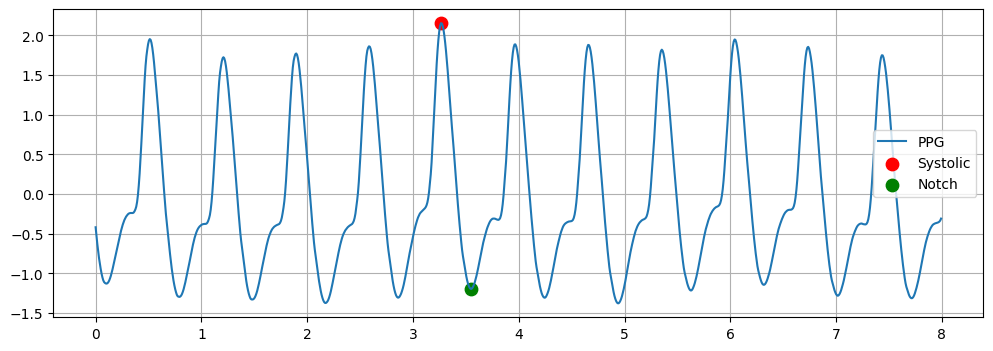

In [34]:
import matplotlib.pyplot as plt
import numpy as np

t = np.arange(1000) / 125

plt.figure(figsize=(12,4))
plt.plot(t, ppg_window, label="PPG")

if sys_idx is not None:
    plt.scatter(
        t[sys_idx],
        ppg_window[sys_idx],
        c="red",
        s=80,
        label="Systolic"
    )

if notch_idx is not None:
    plt.scatter(
        t[notch_idx],
        ppg_window[notch_idx],
        c="green",
        s=80,
        label="Notch"
    )

plt.legend()
plt.grid(True)
plt.show()